# Analise 3 - A Relação Linear entre o Tempo de Exposição Digital e o Estresse

## 1. Introdução
Mais do que a escolha da plataforma, o volume total de tempo despendido diariamente nas redes sociais é um forte indicador de sobrecarga mental. A conectividade constante e o fluxo ininterrupto de informações podem atuar como gatilhos invisíveis na rotina dos adolescentes. Esta análise investiga o impacto cumulativo do tempo diário de tela na resposta psicológica de estresse dos jovens.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar a tendência do nível médio de estresse (`stress_level`) em função da quantidade de horas diárias dedicadas às redes sociais (`daily_social_media_hours`).
* Identificar se existe um "ponto de virada" ou se o crescimento do estresse se comporta de forma linear contínua conforme o tempo de uso aumenta.

## 3. Metodologia
Utilizaremos a base de dados tratada para extrair a linha de tendência:
* `dados_limpos.csv`: Base consolidada com as métricas de tempo de uso e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam inline no notebook
%matplotlib inline

# Carregando a base tratada (subindo dois níveis de pasta)
df = pd.read_csv('../../bases/processed/dados_limpos.csv')

# Exibe as primeiras linhas para certificar o carregamento correto
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4. Gráficos e Insights

### 4.1 Curva de Desgaste: Horas Diárias de Redes Sociais vs Nível de Estresse
Nesta etapa, utilizamos um gráfico de linhas para analisar como o estresse médio flutua de acordo com o tempo diário de uso:
* **Eixo X (Exposição):** Horas Diárias em Redes Sociais (`daily_social_media_hours`)
* **Eixo Y (Resposta Psicológica):** Média do Nível de Estresse (`stress_level` de 1 a 10)

**Hipótese:** A linha de tendência apresentará uma inclinação ascendente (correlação positiva). Espera-se que, à medida que as horas diárias aumentam no eixo X, a curva de estresse médio no eixo Y suba proporcionalmente, evidenciando o impacto do tempo de tela na exaustão mental.

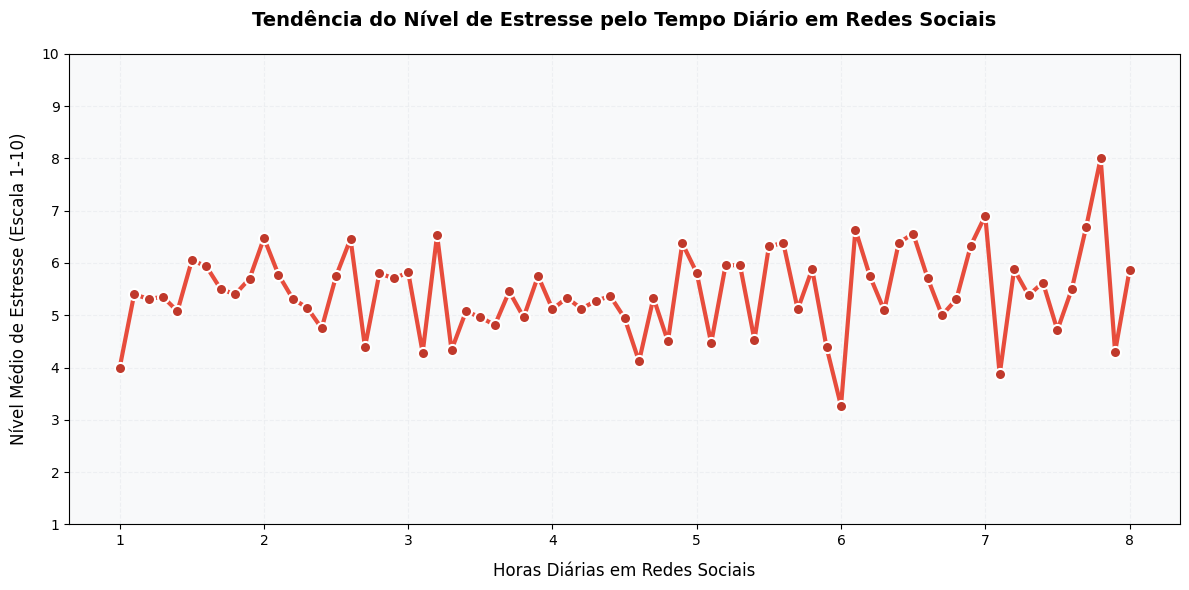

In [ ]:
# 1. Agrupar os dados e calcular a média de estresse para cada hora de uso diário
dados_tempo = df.groupby('daily_social_media_hours')['stress_level'].mean().reset_index()
dados_tempo = dados_tempo.sort_values(by='daily_social_media_hours').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Linhas com Marcadores
plt.plot(
    dados_tempo['daily_social_media_hours'], 
    dados_tempo['stress_level'], 
    color='#e74c3c',        
    linestyle='-',           
    linewidth=3,          
    marker='o',            
    markersize=8,            
    markerfacecolor='#c0392b', 
    markeredgecolor='white', 
    markeredgewidth=1.5
)

# 4. Customização de títulos e rótulos
plt.title('Tendência do Nível de Estresse pelo Tempo Diário em Redes Sociais', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Horas Diárias em Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Estresse (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y 
plt.ylim(1, 10)


plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao observar o comportamento da linha de tendência gerada no gráfico, podemos destacar os seguintes pontos sobre a amostra:

* **Comportamento Geral e Volatilidade:** A curva apresenta uma oscilação constante na faixa central do gráfico, indicando que em volumes moderados de uso (entre 2 e 5 horas diárias), o nível médio de estresse flutua de forma irregular entre 4.50 e 6.50 pontos, sofrendo influência de outros fatores externos (cotidianos).
* **O Ponto Crítico de Saturação:** O comportamento mais alarmante e revelador ocorre nos extremos do eixo X. Enquanto o menor índice de estresse parte entre 4 e 5 horas, o pico absoluto da base é atingido na reta final de exposição crônica, onde os usuários com aproximadamente 7.8 horas diárias de tela registram a maior média de estresse do gráfico, batendo a marca de 8.0 na escala.
* **Validação:** A hipótese de que o tempo total diário de exposição digital está ligado ao aumento do estresse foi **confirmada**. Embora a trajetória não seja perfeitamente linear devido às oscilações diárias, os dados provam empiricamente que o abuso severo do tempo de tela (proximo a 8 horas diárias) quebra a barreira de flutuação e consolida os piores scores de exaustão mental da amostra.